# Description

Look at how peak SWE, frozen days, and winter precipitation changes with temperature in the SNOTEL data

# Load analysis functions

In [1]:
%run /home/nicknish/snowpack/imports.ipynb
%run /home/nicknish/snowpack/snotelAnalysis/pythonSNOTELFunctions/snotelAnalysisFunctions.ipynb

# Load data

add choice for loading all stations or just biased corrected stations...

In [10]:
stationBiasDict = loadTempBiasMarker()

In [11]:
rootPath = '...../snotelData/raw/'
stateNames = ['CO','AK','AZ','CA','ID','MT','NM','NV','OR','SD','UT','WA','WY']
metaData = loadStationMetaData()

In [12]:
allStateDict = {}
for stateName in tqdm(stateNames):
    stateFileNames = glob.glob(rootPath + stateName + '/' + '*')
    stateDataAll = [csvToXarray(f) for f in stateFileNames]
    stateDataCleaned = [s for s in stateDataAll if s.BAD_DATA==False]
    allStateDict[stateName] = stateDataCleaned

100%|██████████| 13/13 [00:13<00:00,  1.04s/it]


In [13]:
## Filter stations with the same functions used in other notebooks ##
allStateDict_filtered = filterStations(stateNames,allStateDict)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 88/89         

# Compute metrics

In [14]:
Tw_stationClim = np.array([])
dlogSWE_dTw = np.array([])
dlogTauF_dTw = np.array([])
dlogPw_dTw = np.array([])

stationNames = []

for iState,stateName in enumerate(stateNames):
    currStateData = allStateDict_filtered[stateName]
    for iS,currStation in (enumerate(currStateData)):
        print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
        stationNames = stationNames + [currStation.name + stateName]
        currStationWYs = np.unique(currStation.water_year.values)
        currStation_Tw = np.array([]) # winter mean temperatures
        currStation_Pw = np.array([])
        currStation_SWEmax = np.array([])
        currStation_tauF = np.array([])
        for WY in currStationWYs:
            currWY = currStation.sel(time=(currStation.water_year == WY))
            currT = currWY.T_avg
            currP = currWY.prcp
            currTime = currWY.time
            # remove any obviously erroneous temperature values (i.e. way to warm)
            currT[currT>40] = np.nan
            currTInterp = fillNANTemp(currT.values)
            currPInterp = fillNANPrcp(currP.values) 
            winterInds = np.logical_or(currTime.dt.month >= 11,currTime.dt.month <= 3)
            
            # calculate Tw and Pw for this specific water year
            Tw = np.nanmean(currTInterp[winterInds])
            Pw = np.nanmean(currPInterp[winterInds])
            
            currSWE = currWY.swe
            SWEmax = np.nanmax(currSWE.values)
            
            currStation_Tw = np.append(currStation_Tw,Tw)
            currStation_Pw = np.append(currStation_Pw,Pw)
            currStation_SWEmax = np.append(currStation_SWEmax,SWEmax)
            currTauF = numberOfFreezingDays(currTInterp)
            currStation_tauF = np.append(currStation_tauF,currTauF)
             
        # SWE sensitivity
        params,cov = np.polyfit(currStation_Tw[np.argsort(currStation_Tw)],np.log(currStation_SWEmax[np.argsort(currStation_Tw)]),1,cov=True)
        slope_Tw_vs_logSWEmax = params[0]
        dlogSWE_dTw = np.append(dlogSWE_dTw,slope_Tw_vs_logSWEmax)
        dlogSWE_dTw_std = np.append(dlogSWE_dTw_std,np.sqrt(cov[0][0]))
                
        # tau_F sensitivity
        slope_Tw_vs_logTauF = np.polyfit(currStation_Tw[np.argsort(currStation_Tw)],np.log(currStation_tauF[np.argsort(currStation_Tw)]),1)[0]
        dlogTauF_dTw = np.append(dlogTauF_dTw,slope_Tw_vs_logTauF)
             
        # Pw sensitivity
        slope_Tw_vs_logPw = np.polyfit(currStation_Tw[np.argsort(currStation_Tw)],np.log(currStation_Pw[np.argsort(currStation_Tw)]),1)[0]
        dlogPw_dTw = np.append(dlogPw_dTw,slope_Tw_vs_logPw)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

# Putting it all together

In [34]:
def createXYLabel(xData,yData,unitY = False):
    unitString = '\n [% K$^{-1}$]'
    if all(xData==Tw_stationClim):
        xLabel = r'Climatological winter-mean temperature [$\degree$C]'
      
    if unitY:
        if all(yData == dlogSWE_dTw*100):
            yLabel = r'$\frac{\partial}{\partial T_\text{w}}$' + unitString
        elif all(yData == dlogTauF_dTw*100):
            yLabel = r'$\frac{\partial}{\partial T_\text{w}}$' + unitString
        elif all(yData == dlogPw_dTw*100):
            yLabel = r'$\frac{\partial}{\partial T_\text{w}}$' + unitString
    else:
        if all(yData == dlogSWE_dTw*100):
            yLabel = r'$\frac{\partial}{\partial T_\text{w}}$' + unitString
        elif all(yData == dlogTauF_dTw*100):
            yLabel = r'$\frac{\partial}{\partial T_\text{w}}$' + unitString
        elif all(yData == dlogPw_dTw*100):
            yLabel = r'$\frac{\partial}{\partial T_\text{w}}$' + unitString
    
    return xLabel,yLabel

## Additive Sensitivity Figure

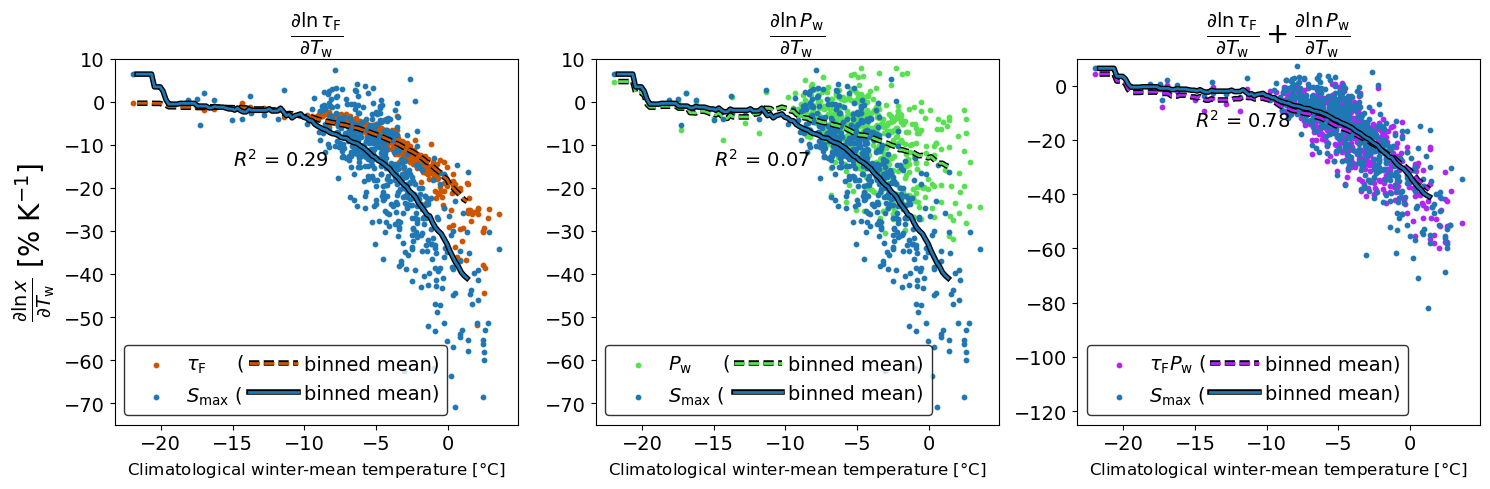

In [95]:
fig,axs = plt.subplots(1,3,figsize=(15,5))

unitYBool = 1

### Panel 1 ###
rowColor = '#CC5500'
ax1 = axs[0]
xData = Tw_stationClim
yData = dlogTauF_dTw*100
yData0 = dlogSWE_dTw*100
ax1.scatter(xData,yData,10,c=rowColor,label=r'$\tau_\text{F}$')
binMidPt,binnedMean = binMeanFunction(yData,xData,5,.2)
ax1.plot(binMidPt,binnedMean,linewidth=2,color=rowColor,linestyle='--',label=r'$\tau_\text{F}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax1.scatter(xData,yData0,10,label=r'$S_\text{max}$')
binMidPt,binnedMean = binMeanFunction(yData0,xData,5,.2)
ax1.plot(binMidPt,binnedMean,linewidth=2,linestyle='-',label=r'$S_\text{max}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
#xLabel,yLabel = createXYLabel(xData,yData,unitYBool)
ax1.set_ylabel(r'$\frac{\partial \ln x}{\partial T_\text{w}}$ [% K$^{-1}$]',rotation=90,labelpad=5,fontsize=20)#\\frac{\\partial x}{\\partial T_\\text{w}}$ [% K$^{-1}$]',rotation=90,labelpad=5,fontsize=20)
ax1.set_xlabel(xLabel,fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_ylim([-75,10])
ax1.set_title(r'$\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}}$',fontsize=20)
ax1.text(-15,-15,fr'$R^2$ = {round(R2_from1to1(yData,yData0),2)}',fontsize=14)

handles, labels = ax1.get_legend_handles_labels()
handles_ordered_arr = np.array(handles).reshape(2, 2).T
handles_ordered = handles_ordered_arr.flatten()
ax1.legend(handles_ordered, ('$\\tau_\\text{F}$     (', '$S_\\text{max}$ (', 'binned mean)', 'binned mean)'),
          loc='lower left', ncol=2, handlelength=2.5, edgecolor='black',
           handletextpad=0.3, columnspacing=0.2,fontsize=14)


### Panel 2 ###
rowColor = '#59E052'
ax2 = axs[1]
xData = Tw_stationClim
yData = dlogPw_dTw*100
yData0 = dlogSWE_dTw*100
ax2.scatter(xData,yData,10,label=r'$P_\text{w}$',c=rowColor)
binMidPt,binnedMean = binMeanFunction(yData,xData,5,.2)
ax2.plot(binMidPt,binnedMean,linewidth=2,color=rowColor,linestyle='--',label=r'$P_\text{w}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax2.scatter(xData,yData0,10,label=r'$S_\text{max}$')
binMidPt,binnedMean = binMeanFunction(yData0,xData,5,.2)
ax2.plot(binMidPt,binnedMean,linewidth=2,linestyle='-',label=r'$S_\text{max}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
xLabel,yLabel = createXYLabel(xData,yData,unitYBool)
#ax2.set_ylabel(yLabel,rotation=0,labelpad=40)
ax2.set_xlabel(xLabel,fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_ylim([-75,10])
ax2.set_title(r'$\frac{\partial \ln P_\text{w}}{\partial T_\text{w}}$',fontsize=20)
ax2.text(-15,-15,fr'$R^2$ = {round(R2_from1to1(yData,yData0),2)}',fontsize=14)

handles, labels = ax2.get_legend_handles_labels()
handles_ordered_arr = np.array(handles).reshape(2, 2).T
handles_ordered = handles_ordered_arr.flatten()
ax2.legend(handles_ordered, ('$P_\\text{w}$     (', '$S_\\text{max}$ (', 'binned mean)', 'binned mean)'),
          loc='lower left', ncol=2, handlelength=2.5, edgecolor='black',
           handletextpad=0.3, columnspacing=0.2,fontsize=14)

### Panel 3 ###
rowColor = '#B027F5'
ax3 = axs[2]
xData = Tw_stationClim
yData = (dlogPw_dTw+dlogTauF_dTw)*100
yData0 = dlogSWE_dTw*100
ax3.scatter(xData,yData,10,label=r'$\tau_\text{F} P_\text{w}$',c=rowColor)
binMidPt,binnedMean = binMeanFunction(yData,xData,5,.2)
ax3.plot(binMidPt,binnedMean,linewidth=2,color=rowColor,linestyle='--',label=r'binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax3.scatter(xData,yData0,10,label=r'$S_\text{max}$')
binMidPt,binnedMean = binMeanFunction(yData0,xData,5,.2)
ax3.plot(binMidPt,binnedMean,linewidth=2,linestyle='-',label=r'$S_\text{max}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
xLabel,yLabel = createXYLabel(xData,yData0,unitYBool)
#ax3.set_ylabel(yLabel,rotation=0,labelpad=40)
ax3.set_xlabel(xLabel,fontsize=12)
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.set_ylim([-125,10])
ax3.set_title(r'$\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}} + \frac{\partial \ln P_\text{w}}{\partial T_\text{w}}$',fontsize=20)
ax3.text(-15,-15,fr'$R^2$ = {round(R2_from1to1(yData,yData0),2)}',fontsize=14)

handles, labels = ax3.get_legend_handles_labels()
handles_ordered_arr = np.array(handles).reshape(2, 2).T
handles_ordered = handles_ordered_arr.flatten()
ax3.legend(handles_ordered, (r'$\tau_\text{F}P_\text{w}$ (', '$S_\\text{max}$ (', 'binned mean)', 'binned mean)'),
          loc='lower left', ncol=2, handlelength=2.5, edgecolor='black',
           handletextpad=0.3, columnspacing=0.2,fontsize=14)

plt.tight_layout()

In [17]:
# save this data for final plot
saveBool = True
if saveBool:
    pathToSave = '...../figureData'
    np.savez(pathToSave + '/figure5AddedSen.npz',
             TwClim = Tw_stationClim,
             dlogPw_dTw = dlogPw_dTw*100,
             dlogTauF_dTw = dlogTauF_dTw*100,
             dlogSWE_dTw = dlogSWE_dTw*100,
            )